In [ ]:
import pandas as pd
import re
#Load Data
df = pd.read_csv("resume_dataset_cleaned.csv")

# Cleaning
def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'\s+', ' ', text.strip())
    text = re.sub(r'[^a-zA-Z0-9,.\-\s]', '', text)
    return text.lower()

text_columns = ["Skills", "Target_Job_Description", "Field_of_Study", "Degrees"]
for col in text_columns:
    df[col] = df[col].apply(clean_text)

# Combine relevant text
df["combined_text"] = (
    df["Skills"].fillna('') + " " +
    df["Target_Job_Description"].fillna('') + " " +
    df["Field_of_Study"].fillna('') + " " +
    df["Degrees"].fillna('')
)

print(df[["Name", "combined_text"]].head())

               Name                                      combined_text
0      Akash Pillai  node.js javascript deep learning statistics sq...
1  Charlotte Taylor  spark kubernetes terraform natural language pr...
2        James Zhou  data analysis node.js machine learning linux j...
3     Amelia Thomas  docker kubernetes blockchain spark targeting a...
4       Amanda Jain  statistics blockchain kubernetes cybersecurity...


In [ ]:
# Load roles dataset
roles_df = pd.read_csv("roles_dataset.csv")

# Strip spaces and normalize case
roles_df["Current_Job_Title"] = roles_df["Current_Job_Title"].str.strip().str.lower()
roles_df["Role_Label"] = roles_df["Role_Label"].str.strip().str.title()

# Drop duplicates, just in case
roles_df = roles_df.drop_duplicates()

# Preview
print(roles_df.head())


               Name       Current_Job_Title  \
0      Akash Pillai               developer   
1  Charlotte Taylor  cybersecurity engineer   
2        James Zhou         prompt engineer   
3     Amelia Thomas             ai engineer   
4       Amanda Jain  cybersecurity engineer   

                              Target_Job_Description              Role_Label  
0  Seeking a challenging role as a Software Devel...       Software Engineer  
1  Targeting a Cybersecurity Engineer position to...  Cybersecurity Engineer  
2  Targeting a Prompt Engineer position to utiliz...         Prompt Engineer  
3  Targeting a Data Scientist position where I ca...             Ai Engineer  
4  Looking for an opportunity as a Prompt Enginee...  Cybersecurity Engineer  


In [ ]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 49.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as esw

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import spacy
import re


In [ ]:
nlp = spacy.load("en_core_web_md")

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc if not token.is_stop)

df["combined_text"] = df["combined_text"].apply(lemmatize_text)

extra_resume_stopwords = [
    'role','seek','contribute','apply','skill','organizational',
    'growth','challenging','challenging role','seek challenging',
    'success','professional','contribute organizational','knowledge',
    'organizational success','knowledge contribute','skill knowledge',
    'success professional','apply skill','professional growth'
]

custom_stop_words = list(esw.union([
    'utilize','drive','results','career','objectives',
    'achieve','position','background','motivated'
] + extra_resume_stopwords))

tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words=custom_stop_words,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(df["combined_text"])
print("TF-IDF shape:", X_tfidf.shape)


pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

print(f"Original features: {X_tfidf.shape[1]} → Reduced to {X_pca.shape[1]}")


TF-IDF shape: (1200, 2000)
Original features: 2000 → Reduced to 50


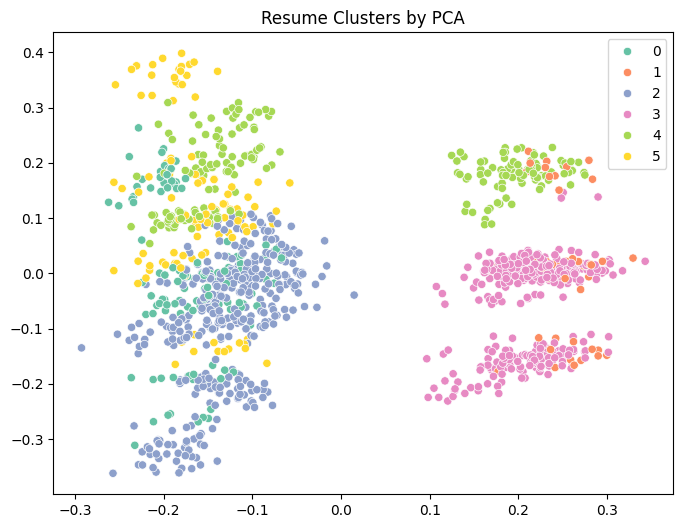

Cluster
2    386
3    336
4    209
0    116
5    105
1     48
Name: count, dtype: int64


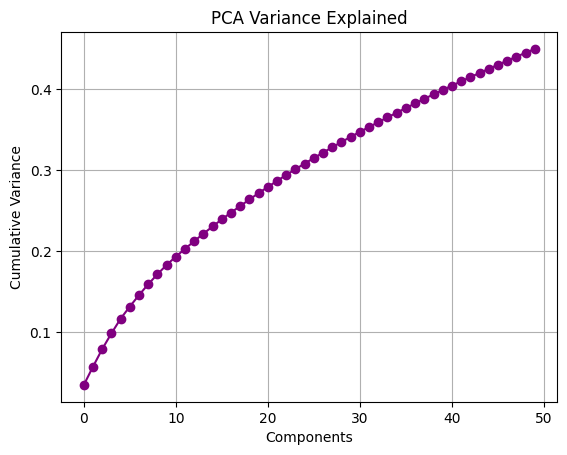

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df["Cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2')
plt.title("Resume Clusters by PCA")
plt.show()

print(df["Cluster"].value_counts())


plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='purple')
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Variance Explained")
plt.grid(True)
plt.show()


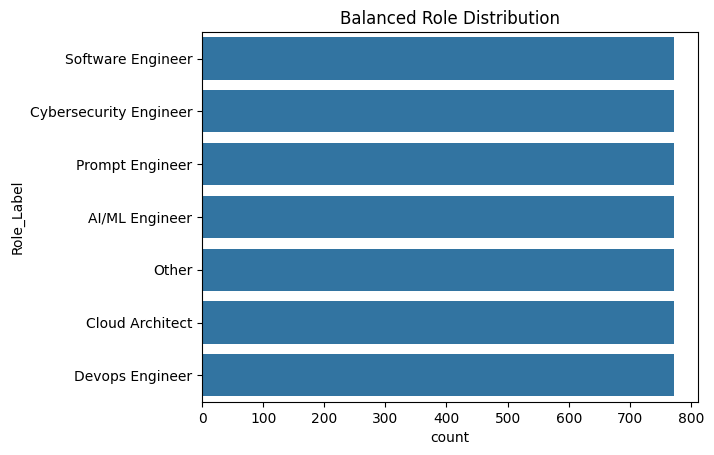

In [ ]:
roles_df = roles_df.drop_duplicates(subset=["Name"])

merged_df = df.merge(roles_df[["Name","Role_Label"]], on="Name", how="inner")

merged_df['Role_Label'] = merged_df['Role_Label'].replace({
    'Ai Engineer': 'AI/ML Engineer',
    'Machine Learning Engineer': 'AI/ML Engineer',
    'Ai Researcher': 'AI/ML Engineer',
    'Data Scientist': 'AI/ML Engineer'
})

merged_df = merged_df.dropna(subset=["Role_Label"])

y = merged_df["Role_Label"]
X_final = X_pca  # already aligned via merge


sm = SMOTE(sampling_strategy='not majority', random_state=42)
X_balanced, y_balanced = sm.fit_resample(X_final, y)

sns.countplot(y=y_balanced)
plt.title("Balanced Role Distribution")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2, random_state=42, stratify=y_balanced
)

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=15,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)


🔍 Random Forest:
                         precision    recall  f1-score   support

        AI/ML Engineer       0.90      0.97      0.93       154
       Cloud Architect       0.97      0.99      0.98       154
Cybersecurity Engineer       0.96      0.97      0.96       155
       Devops Engineer       0.99      0.99      0.99       155
                 Other       0.89      0.77      0.82       155
       Prompt Engineer       0.97      0.99      0.98       155
     Software Engineer       0.93      0.91      0.92       155

              accuracy                           0.94      1083
             macro avg       0.94      0.94      0.94      1083
          weighted avg       0.94      0.94      0.94      1083


🌲 Gradient Boosting:
                         precision    recall  f1-score   support

        AI/ML Engineer       0.85      0.94      0.89       154
       Cloud Architect       0.95      0.99      0.97       154
Cybersecurity Engineer       0.94      0.95      0.94     

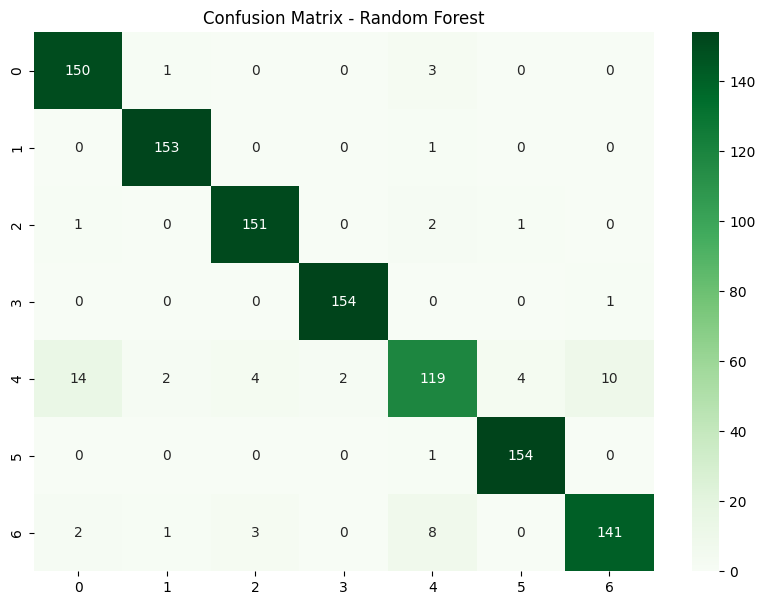

0.9453034034643959 0.04075257473872895


In [ ]:
print("\n🔍 Random Forest:\n", classification_report(y_test, rf_model.predict(X_test)))
print("\n🌲 Gradient Boosting:\n", classification_report(y_test, gb_model.predict(X_test)))

plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, rf_model.predict(X_test)),
            annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()

scores = cross_val_score(rf_model, X_balanced, y_balanced, cv=5)
print(scores.mean(), scores.std())


In [ ]:
results_df = pd.DataFrame({
    "Model": ["Random Forest","Gradient Boosting"],
    "Accuracy": [0.94, 0.91],
    "CV Mean": [scores.mean(), 0.9103],
    "Std Dev": [scores.std(), 0.041]
})
print(results_df)

sns.barplot(x="Accuracy", y="Model", data=results_df, palette="coolwarm")
plt.title("Model Comparison")
plt.show()


NameError: name 'pd' is not defined

In [ ]:
import joblib
joblib.dump(gb_model, "resume_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(pca, "pca_transform.pkl")


NameError: name 'gb_model' is not defined

In [ ]:
!pip install joblib

In [ ]:
import joblib

# Load and test

loaded_model = joblib.load("resume_classifier.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_pca = joblib.load("pca_transform.pkl")

print("Model and components reloaded — ready for inference.")


Model and components reloaded — ready for inference.


In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.6 MB/s eta 0:00:00


In [ ]:
# import streamlit as st
# import pdfplumber, re, joblib, os

# st.title("🧠 AI Resume Role Classifier")

# tfidf = joblib.load("tfidf_vectorizer.pkl")
# pca = joblib.load("pca_transform.pkl")
# model = joblib.load("resume_classifier.pkl")

# def extract_text_from_pdf(pdf_file):
#     text = ""
#     with pdfplumber.open(pdf_file) as pdf:
#         for page in pdf.pages:
#             page_text = page.extract_text()
#             if page_text:
#                 text += "\n" + page_text
#     return text

# def clean_text(txt):
#     txt = re.sub(r'\s+', ' ', txt.strip())
#     txt = re.sub(r'[^a-zA-Z0-9,.\- ]', '', txt)
#     return txt.lower()

# st.write("Upload your resume (PDF only):")
# uploaded_file = st.file_uploader("", type=["pdf"])

# if uploaded_file:
#     text = clean_text(extract_text_from_pdf(uploaded_file))
#     tfidf_vec = tfidf.transform([text])
#     pca_vec = pca.transform(tfidf_vec.toarray())
#     role = model.predict(pca_vec)[0]
#     st.success(f"Predicted Role: **{role}**")


In [ ]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib import colors
import random
import os

def generate_realistic_resume(file_path="random_resume.pdf"):
    # Fake name pool
    first_names = ["Aarav", "Riya", "Kabir", "Sarah", "Zane", "Priya", "Leo", "Mira", "Aditya", "Ethan"]
    last_names = ["Sharma", "Patel", "Singh", "Verma", "Iqbal", "Gupta", "Roy", "Nair", "Chen", "Walker"]

    name = f"{random.choice(first_names)} {random.choice(last_names)}"

    email = f"{name.lower().replace(' ','.')}@gmail.com"
    phone = f"+91-{random.randint(60000,99999)}-{random.randint(10000,99999)}"

    roles = [
        "AI Engineer",
        "Machine Learning Engineer",
        "Cloud Architect",
        "Software Engineer",
        "Prompt Engineer",
        "Data Scientist",
        "Cybersecurity Engineer",
        "DevOps Engineer"
    ]

    role = random.choice(roles)

    # Role-specific skills + general skills
    role_skills = {
        "AI Engineer": ["Neural Networks", "Deep Learning", "TensorFlow", "Computer Vision"],
        "Machine Learning Engineer": ["Regression", "XGBoost", "Feature Engineering", "MLOps"],
        "Cloud Architect": ["AWS", "Azure", "GCP", "Infrastructure as Code", "Docker", "Kubernetes"],
        "Software Engineer": ["OOP", "Java", "C++", "APIs", "System Design"],
        "Prompt Engineer": ["LLMs", "Prompt Chaining", "RAG", "ChatGPT API"],
        "Data Scientist": ["Statistics", "Visualization", "Pandas", "Hypothesis Testing"],
        "Cybersecurity Engineer": ["Vulnerability Scanning", "Firewalls", "Encryption", "SIEM"],
        "DevOps Engineer": ["CI/CD", "Docker", "Jenkins", "Monitoring", "Linux"]
    }

    general_skills = ["Python", "SQL", "Git", "Teamwork", "Communication"]

    selected_role_skills = random.sample(role_skills[role], k=3)
    selected_general_skills = random.sample(general_skills, k=3)

    skills = selected_role_skills + selected_general_skills

    experience_templates = {
        "AI Engineer": [
            "Built and trained deep learning models achieving high accuracy.",
            "Optimized neural network pipelines for faster inference."
        ],
        "Machine Learning Engineer": [
            "Designed ML pipelines and automated training workflows.",
            "Tuned ML models using hyperparameter optimization."
        ],
        "Cloud Architect": [
            "Designed scalable cloud solutions across AWS/GCP.",
            "Managed CI/CD deployments using Docker & Kubernetes."
        ],
        "Software Engineer": [
            "Developed backend services with Python and Java.",
            "Implemented REST APIs with optimized performance."
        ],
        "Prompt Engineer": [
            "Created complex LLM prompts improving logical coherence.",
            "Designed multi-step reasoning chains for chatbots."
        ],
        "Data Scientist": [
            "Performed exploratory data analysis and visualization.",
            "Built analytical models to derive insights from data."
        ],
        "Cybersecurity Engineer": [
            "Conducted vulnerability assessments and threat analysis.",
            "Implemented secure authentication mechanisms."
        ],
        "DevOps Engineer": [
            "Built CI/CD pipelines using Jenkins and Docker.",
            "Automated infrastructure monitoring and logging."
        ],
    }

    experience = random.sample(experience_templates[role], k=2)

    projects = [
        "Developed intelligent resume classifier using ML techniques.",
        "Created cloud-hosted microservice for automation.",
        "Implemented end-to-end chatbot system with LLM integration.",
        "Built predictive model improving KPI forecasting accuracy."
    ]

    selected_projects = random.sample(projects, k=2)

    education = [
        "B.Tech in Computer Science Engineering",
        "B.Tech in Information Technology",
        "B.Sc in Data Science",
        "M.Tech in Artificial Intelligence"
    ]
    edu_choice = random.choice(education)

    # ==== PDF GENERATION ====

    c = canvas.Canvas(file_path, pagesize=letter)
    width, height = letter
    y = height - 40

    # Name
    c.setFont("Helvetica-Bold", 18)
    c.drawString(50, y, name)
    y -= 25

    # Contact Info
    c.setFont("Helvetica", 10)
    c.drawString(50, y, f"Email: {email}")
    y -= 15
    c.drawString(50, y, f"Phone: {phone}")
    y -= 25

    # Summary
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, "Professional Summary:")
    y -= 20

    summary = f"Enthusiastic {role} with hands-on experience and passion for solving real-world problems."
    c.setFont("Helvetica", 10)
    for line in summary.split(". "):
        c.drawString(60, y, line.strip())
        y -= 15

    y -= 10

    # Skills
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, "Skills:")
    y -= 20

    c.setFont("Helvetica", 10)
    for s in skills:
        c.drawString(70, y, f"- {s}")
        y -= 15

    y -= 10

    # Experience
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, "Experience:")
    y -= 20

    c.setFont("Helvetica", 10)
    for exp in experience:
        c.drawString(70, y, f"- {exp}")
        y -= 15

    y -= 10

    # Projects
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, "Projects:")
    y -= 20

    c.setFont("Helvetica", 10)
    for p in selected_projects:
        c.drawString(70, y, f"- {p}")
        y -= 15

    y -= 10

    # Education
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, y, "Education:")
    y -= 20

    c.setFont("Helvetica", 10)
    c.drawString(70, y, f"- {edu_choice}")

    c.save()
    return file_path

# Generate Resume
pdf_path = generate_realistic_resume()
print("Generated:", pdf_path)


Generated: random_resume.pdf


In [ ]:
import os
import sys
def path_exists(path):
  if not os.path.exists(path):
    print("Path doesn't exist !\n")
    sys.exit(1)
  else:
    return path

In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 33.6 MB/s eta 0:00:00


In [ ]:
import joblib
import pdfplumber
import re
import os
# === Step 7.1: Load saved models ===
tfidf = joblib.load("tfidf_vectorizer.pkl")
pca = joblib.load("pca_transform.pkl")
model = joblib.load("resume_classifier.pkl")  # or rf_model if you prefer
pdf_path=path_exists("/content/random_resume.pdf")
# === Step 7.2: Function to parse a new resume PDF ===
def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += "\n" + page_text
    return text

# === Step 7.3: Light cleaning ===
def clean_text(txt):
    txt = re.sub(r'\s+', ' ', txt.strip())
    txt = re.sub(r'[^a-zA-Z0-9,.\- ]', '', txt)
    return txt.lower()

# === Step 7.4: Make a prediction ===
def predict_role(pdf_path):
    text = extract_text_from_pdf(pdf_path)
    text = clean_text(text)
    stop_phrase=['utilize', 'drive', 'results', 'career', 'objectives']
    for phrase in stop_phrase:
      text.replace(phrase,'')

    # Vectorize using saved TF-IDF
    tfidf_vec = tfidf.transform([text])

    # Apply PCA transform
    pca_vec = pca.transform(tfidf_vec.toarray())

    # Predict with your trained model
    predicted_role = model.predict(pca_vec)[0]
    return predicted_role

# === Example usage ===
predicted = predict_role(pdf_path)
print("🎯 Predicted Role:", predicted)

🎯 Predicted Role: Prompt Engineer


In [ ]:
#import numpy as np

#feature_names = np.array(tfidf.get_feature_names_out())
#sorted_idx = np.argsort(pca.components_[0])
#print(feature_names[sorted_idx[-20:]])  # top 20 high-weighted tokens


['sale' 'project management' 'human resource' 'human' 'customer'
 'operation' 'patient care' 'care' 'accounting' 'communication' 'content'
 'patient' 'medium' 'social medium' 'social' 'psychology' 'financial'
 'manager' 'marketing' 'management']


In [ ]:
#feature_names = tfidf.get_feature_names_out()
#vec = tfidf.transform([extract_text_from_pdf("/content/Resume.pdf")])
#present_words = [feature_names[i] for i in vec.nonzero()[1]]
#print(present_words[:50])


['ai', 'algorithm', 'clean', 'cloud', 'code', 'computer', 'computer science', 'data', 'deployment', 'development', 'education', 'efficiency', 'engineering', 'google', 'google cloud', 'learn', 'learning', 'machine', 'machine learning', 'model', 'performance', 'problem', 'programming', 'project', 'python', 'python sql', 'science', 'sql', 'technology', 'tensorflow', 'time', 'user']


In [ ]:
!pip install gradio
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.5 MB/s eta 0:00:00


In [ ]:
import gradio as gr
import pdfplumber
import joblib
import re

# Load model files
tfidf = joblib.load("tfidf_vectorizer.pkl")
pca = joblib.load("pca_transform.pkl")
model = joblib.load("resume_classifier.pkl")

In [ ]:
def extract_text_from_pdf(file_obj):
    text = ""
    with pdfplumber.open(file_obj) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += "\n" + page_text
    return text

def clean_text(txt):
    txt = re.sub(r"\s+", " ", txt.strip())
    txt = re.sub(r"[^a-zA-Z0-9,.\- ]", "", txt)
    return txt.lower()

def predict_resume_role(pdf_file):
    text = extract_text_from_pdf(pdf_file)
    cleaned = clean_text(text)
    tfidf_vec = tfidf.transform([cleaned])
    pca_vec = pca.transform(tfidf_vec.toarray())
    role = model.predict(pca_vec)[0]
    return f"Predicted Role: {role}"


In [ ]:
with gr.Blocks() as demo:
    gr.Markdown("# 🧠 AI Resume Analyzer Dashboard\nUpload a PDF resume to classify its job role.")

    pdf_input = gr.File(label="Upload Resume (PDF)")
    output = gr.Textbox(label="Prediction Output")

    analyze_btn = gr.Button("Analyze Resume")

    analyze_btn.click(
        fn=predict_resume_role,
        inputs=pdf_input,
        outputs=output
    )

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ecddd2f99431e84493.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
